# Unit 4：MNE 中 ICA 实战

## 目标
- 掌握 MNE ICA 的标准流水线
- 学会 ICA 拟合、成分可视化、识别与剔除
- 理解每个步骤的注意事项


### 4.1 ICA 处理流水线

```Text
原始 EEG
  ↓
① 滤波 (1-40 Hz 带通)      ← 去漂移和高频噪声，利于 ICA 收敛
  ↓
② 剔除大伪迹段 (reject)    ← 大幅值异常会绑架 ICA 成分
  ↓
③ ICA 拟合                 ← 数据干净才能得到好分解
  ↓
④ 成分可视化 & 识别         ← 地形图 + 时间序列 + 功率谱
  ↓
⑤ 剔除伪迹成分             ← apply 到原始/滤波后数据
  ↓
干净 EEG
```


### 4.2 步骤①：滤波

**为什么 ICA 前要滤波？**
- 高通（1 Hz）：去除 DC 漂移，漂移不是独立成分
- 低通（40 Hz）：去除肌电高频噪声，它们也不满足 ICA 的线性混合假设


Opening raw data file d:\AI\qwenpaw\eeg_ica_learning\datasets\MNE-sample-data\MEG\sample\sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)



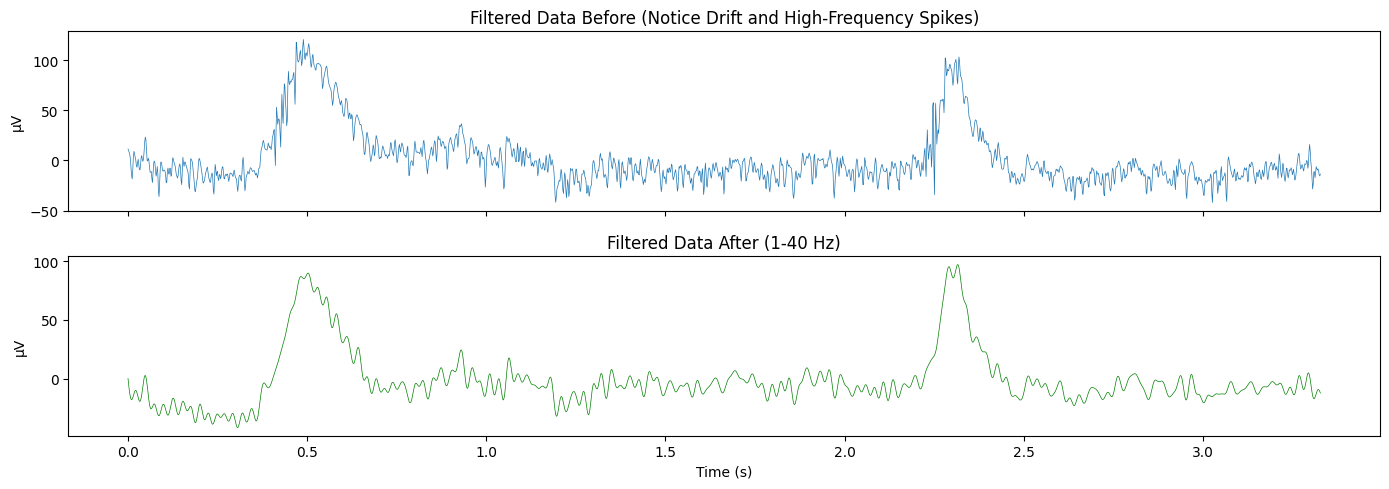

✅ 注意滤波前漂移和高频尖峰


In [42]:
import os
import mne
import numpy as np
import matplotlib.pyplot as plt


data_dir = os.path.abspath("./../datasets")
os.makedirs(data_dir, exist_ok=True)
mne.set_config("MNE_DATA", data_dir)
mne.set_config("MNE_DATASETS_SAMPLE_PATH", data_dir)

sample_data_dir = mne.datasets.sample.data_path()
raw_fname = sample_data_dir / 'MEG' / 'sample' / 'sample_audvis_raw.fif'

raw = mne.io.read_raw_fif(raw_fname, preload=True)
raw.pick(['eeg'])

# 带通滤波
raw_filtered = raw.copy().filter(l_freq=1.0, h_freq=40.0)

# 对比
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
before = raw.get_data(picks='EEG 001')[0, :2000]
after  = raw_filtered.get_data(picks='EEG 001')[0, :2000]
times  = raw.times[:2000]
axes[0].plot(times, before*1e6, linewidth=0.5)
axes[0].set_ylabel('μV'); axes[0].set_title('Filtered Data Before (Notice Drift and High-Frequency Spikes)')
axes[1].plot(times, after*1e6, linewidth=0.5, color='green')
axes[1].set_ylabel('μV'); axes[1].set_title('Filtered Data After (1-40 Hz)')
axes[1].set_xlabel('Time (s)')
plt.tight_layout(); 
plt.show()
print("✅ 注意滤波前漂移和高频尖峰")


### 4.3 步骤②：剔除大伪迹段

FastICA 对大幅值异常敏感，大伪迹会把整个成分"绑架"成那个瞬间的形状。

最佳实践：用 `reject` 参数排除峰峰值过大的时间窗口。  
提出问题：去坏段会破坏真实事件，但是我们此时不是在处理 ERP 的 trial！这是 ICA 预处理 阶段，不是最终分析阶段。ICA 不依赖时间相邻性 ，它只看信号的空间统计分布，少一个时间点不影响。  
核心规则：一人犯错，全家连坐。MNE 的 reject 机制是 按 epoch 整段丢弃 ，不是按通道丢弃。


In [50]:
# 基于峰峰值剔除：任何通道在 1 秒内峰峰值超过 200 μV 的段被排除
# reject 里的数值是 峰峰值阈值 ，不是绝对最大振幅
# 峰峰值 = epoch 内信号最大值 - epoch 内信号最小值
reject_criteria = dict(eeg=200e-6)  # 200 μV {'eeg': 0.0002}
print(f"Reject Criteria: {reject_criteria}")

# 创建 epochs 只是为了用 reject（不用实际上做 epoch）
# 把整段连续数据 等距切分 成 1 秒一段的"虚拟事件"，返回一个事件数组。
events = mne.make_fixed_length_events(raw_filtered, duration=1.0) # shape: (n_events, 3)
epochs = mne.Epochs(
    raw_filtered,    # 输入的滤波后原始数据
    events,          # 事件标记数组（由 make_fixed_length_events 生成的等距事件）
    tmin=0,          # 每个 epoch 的起始时间（相对于事件，单位：秒）
    tmax=0.99,       # 每个 epoch 的结束时间（0.99秒确保正好1秒长度，避免边界问题）
    baseline=None,   # 不进行基线校正
    reject=reject_criteria,  # 拒绝标准：峰峰值超过 200 μV 的 epoch 将被剔除
    preload=True,     # 加载数据并自动剔除坏段
    verbose=False    # 关闭详细输出，减少日志信息
)
print(f"原始 1s 段数: {len(events)}段")
print(f"剔除坏段后: {len(epochs)}段 ({len(events)-len(epochs)} 段被排除)")
print(f"保留数据占比: {len(epochs)/len(events)*100:.1f}%")


Reject Criteria: {'eeg': 0.0002}
原始 1s 段数: 277段
剔除坏段后: 268段 (9 段被排除)
保留数据占比: 96.8%


### 4.4 步骤③：ICA 拟合

**成分数量怎么选？** 这里有 60 个 EEG 通道：
- 太少（如 10 个）→ 伪迹和脑信号挤在同一成分，剔除时误伤脑信号
- 太多（如 40 个）→ 脑信号过度拆分，人工识别负担大
- **推荐 15-25 个**，本教程用 15 个


In [57]:
from mne.preprocessing import ICA

n_components = 15  # ICA 分解的成分数量，通常小于通道数
# 初始化 ICA 对象，用于独立成分分析
ica = ICA(
    n_components=n_components,  # 指定要提取的独立成分数量
    method='fastica',           # 使用 FastICA 算法
    random_state=42,            # 设置随机种子，保证结果可复现
    max_iter='auto',            # 自动设置最大迭代次数
    # 启用扩展 Infomax 算法，提高对亚高斯分布的分离能力
)

print(f"开始 ICA 拟合（{n_components} 个成分，{len(raw_filtered.ch_names)} 个通道）...")
# 60 通道 EEG  ──PCA──▶  15 个 PCA 主成分  ──ICA──▶  15 个独立成分
# 对滤波后的原始数据进行 ICA 拟合，提取独立成分
ica.fit(
    inst=raw_filtered,       # 输入的原始数据，用于拟合 ICA 模型
    verbose=False           # 关闭详细输出，减少日志信息
)
print(f"✅ 完成！迭代次数: {ica.n_iter_}")
# 解释方差比 = 前 15 个成分的方差之和 / 全部成分的方差之和
print(f"解释方差比: {np.sum(ica.pca_explained_variance_[:n_components]) / np.sum(ica.pca_explained_variance_):.1%}")


开始 ICA 拟合（15 个成分，60 个通道）...
✅ 完成！迭代次数: 43
解释方差比: 97.3%


### 4.5 步骤④：成分可视化与识别

三种互补视角来识别伪迹成分：
1. **地形图**（空间分布）—— 前额集中 → 眨眼
2. **时间序列**（时域激活）—— 间歇脉冲 → 眨眼
3. **功率谱**（频域特征）—— 低频主导 → 眼动


地形图,看空间分布

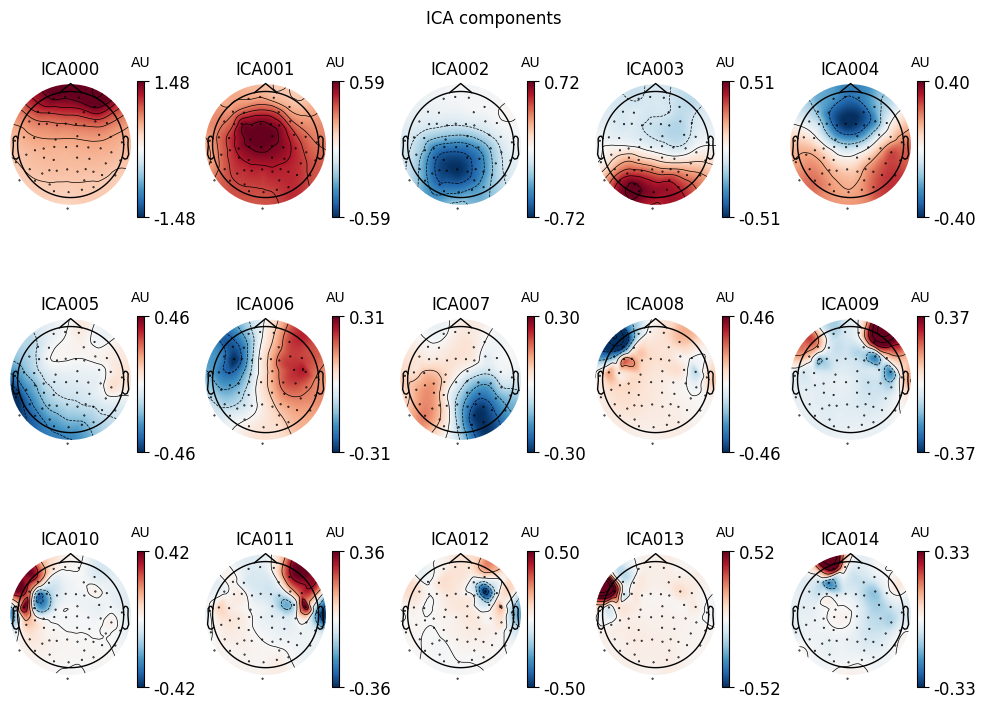

观察要点：前额高亮 → 眨眼/眼动；颞部集中 → 肌电；全头分散 → 可能是心跳


In [58]:
# 方式一：地形图 —— 看空间分布
ica.plot_components(
    picks=range(n_components),
    colorbar=True
)
# AU = Arbitrary Units （任意单位）
print("观察要点：前额高亮 → 眨眼/眼动；颞部集中 → 肌电；全头分散 → 可能是心跳")


时间序列，把 ICA 分解出来的前几个独立成分的时间序列画出来

In [55]:
# 方式二：时间序列 —— 看激活模式
ica.plot_sources(raw_filtered, picks=range(min(20, n_components)))
print("观察要点：1.间歇性大尖峰 → 眨眼；2.规律脉冲 → 心跳；3.持续高频 → 肌电")

Creating RawArray with float64 data, n_channels=15, n_times=166800
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
观察要点：1.间歇性大尖峰 → 眨眼；2.规律脉冲 → 心跳；3.持续高频 → 肌电


功率谱

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
138 matching events found
No baseline correction applied
0 projection items activated


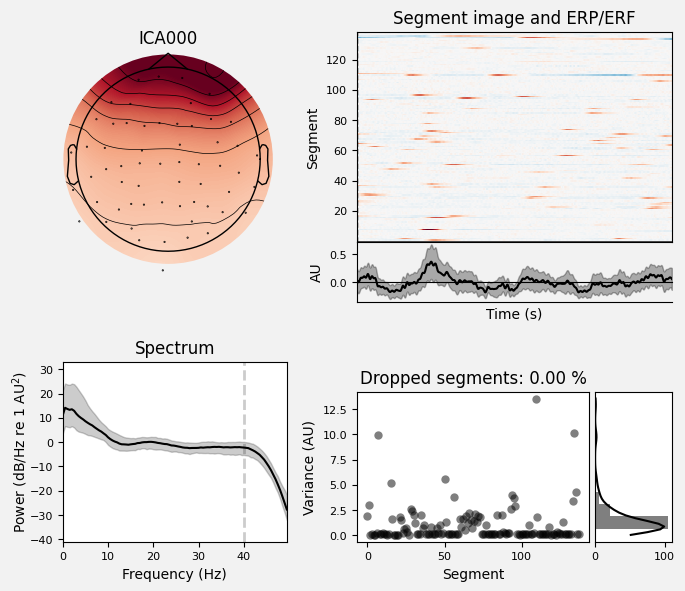

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
138 matching events found
No baseline correction applied
0 projection items activated


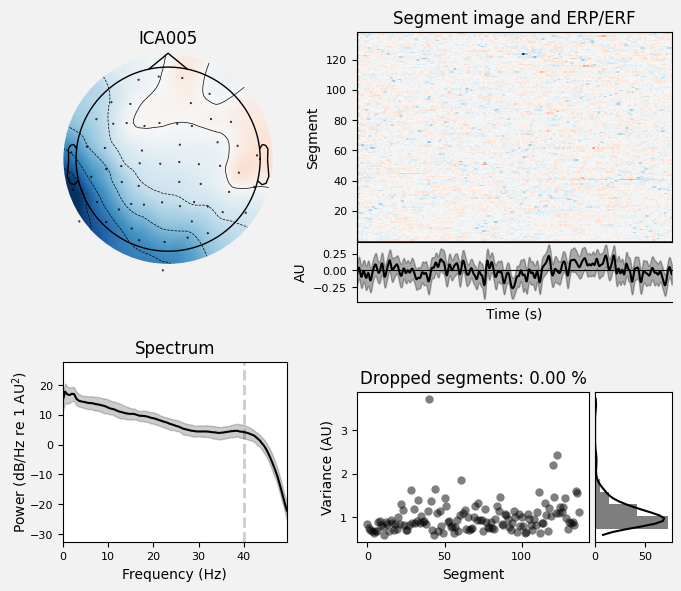

✅ 综合属性已显示


In [59]:
# 方式三：综合属性（地形图 + 时间序列 + 功率谱三合一）
# 先看成分 0，你自己看其他可疑成分
ica.plot_properties(inst=raw_filtered, picks=[0])
ica.plot_properties(inst=raw_filtered, picks=[5])
print("✅ 综合属性已显示")


### 4.6 识别伪迹成分的对照表

| 特征 | 眨眼 | 眼动 | 心跳 | 肌电 |
|------|------|------|------|------|
| 地形图 | 前额集中 🔴 | 单侧/双侧前部 | 分散或特定 | 颞部局部 |
| 时间序列 | 间歇大脉冲 | 缓慢方波/漂移 | 规律尖峰 | 持续高频噪声 |
| 功率谱 | <5 Hz 主导 | <4 Hz 主导 | 5-20 Hz 有峰 | >20 Hz 隆起 |


eog_scores 是每个 ICA 成分“像不像 EOG”的分数；  
threshold 是根据这些分数自动挑出“异常高相关成分”的判定标准。  
>如果某个 ICA 成分的 EOG score 在所有成分里特别突出，超过约 3 个标准差，就把它标记为 EOG 成分。

自动检测到的眼动成分: [np.int64(0)]
与 Fp1 的相关性得分: [ 0.963  0.164 -0.005 -0.053 -0.175 -0.011 -0.06   0.027  0.075 -0.05
 -0.038 -0.016  0.054  0.036 -0.005]

💡 记住这些成分编号，和你的肉眼观察对比。Unit 5 会实际剔除。


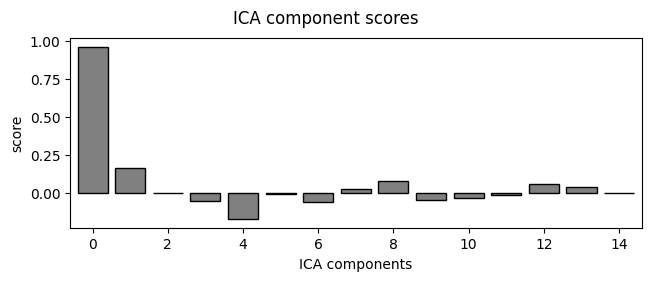

✅ 眼动成分相关性得分已显示


In [60]:
# 自动辅助：用 Fp1 找眼动相关成分
eog_indices, eog_scores = ica.find_bads_eog(
    inst=raw_filtered,  # 应该用滤波后的EEG数据对象
    ch_name='EEG 001',  # 用于检测眼动的参考通道名称（Fp1电极）
    threshold=3.0,      # 基于 eog_scores 的 z-score 异常阈值
    verbose=False       # 不显示详细信息
)
print(f"自动检测到的眼动成分: {eog_indices}")
print(f"与 Fp1 的相关性得分: {np.array2string(eog_scores, precision=3)}")

# ⚠️ 不要盲目相信自动检测！要结合地形图和时间序列人工确认。
print("\n💡 记住这些成分编号，和你的肉眼观察对比。Unit 5 会实际剔除。")

ica.plot_scores(eog_scores)
print("✅ 眼动成分相关性得分已显示")


### 4.7 步骤⑤：剔除伪迹成分




In [61]:
# 标记
ica.exclude = [0, 2]   # 根据前面的观察确定

# 应用到数据
raw_clean = ica.apply(raw_filtered.copy())

# 对比
raw_filtered.plot(n_channels=10, title='ICA 前')
raw_clean.plot(n_channels=10, title='ICA 后')
print("✅ ICA 应用完成")
print("✅ 对比已显示")

Applying ICA to Raw instance


    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 59 PCA components
✅ ICA 应用完成
✅ 对比已显示


### ⚠️ 关键注意事项

1. **叠加因素**：先滤波再 ICA，但 `apply` 可以用在原始数据上
2. **适度剔除**：通常剔除 5-20% 的成分
3. **反复验证**：剔除后检查时间序列和地形图，确认伪迹减少
4. **随机种子**：设 `random_state` 保证可复现

### 🤔 思考题

- 为什么滤波要在 ICA 之前？（想想中心极限定理和非高斯性）
- 成分 0 是眨眼，成分 5 也是眨眼 — 为什么会分成两个成分？

→ 进入 **Unit 5：完整演练**
